In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [ ]:
### Tool -> Internet search using tavily
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)



In [4]:
from langchain.chat_models import init_chat_model

model=init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000189DEE6EA50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000189DEE6F770>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

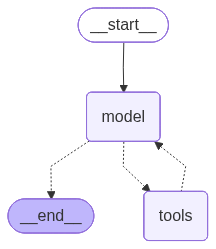

In [ ]:
## Basic Agent -> what we have bulit so far
from langchain.agents import create_agent

simple_agent=create_agent(
    model=model,
    tools=[web_search]
)
simple_agent

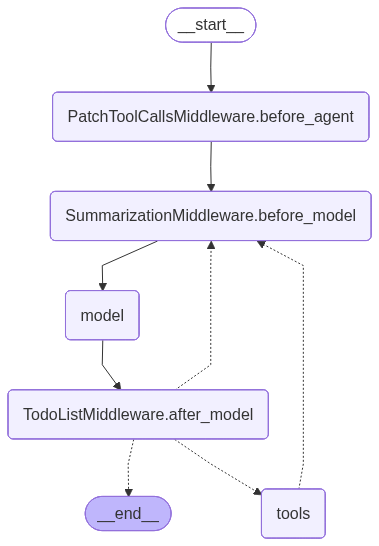

In [ ]:
### Deep agent -> needs prompt too

from deepagents import create_deep_agent

deepagent=create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)
deepagent

In [ ]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})

In [8]:
result["messages"][-1].content

"DeepAgent is an end-to-end deep reasoning agent introduced in a 2025 research paper by Xiaoxi Li and colleagues. It is designed to perform autonomous thinking, tool discovery, and action execution within a single reasoning process. The paper highlights its ability to outperform baseline models across various benchmarks, including general tool-use tasks (e.g., ToolBench, API-Bank) and downstream applications (e.g., ALFWorld, WebShop). Key features include:\n\n1. **Scalable Toolsets**: Integrates diverse tools for tasks like API interactions, web navigation, and environment manipulation.\n2. **General Reasoning**: Capable of handling both structured (API/tool use) and unstructured (natural language) tasks.\n3. **Benchmark Performance**: Demonstrated superior results on eight benchmarks, including ToolHop (tool discovery) and GAIA (complex reasoning).\n\nThe paper ([arXiv:2510.21618](https://arxiv.org/abs/2510.21618)) positions DeepAgent as a versatile agent for real-world applications r

### Customizing Deep Agents

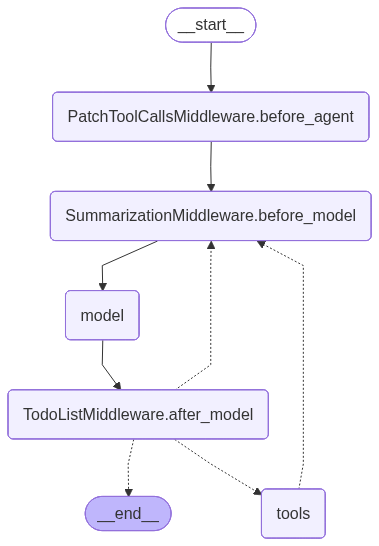

In [10]:
## #Model
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

model = init_chat_model(model="gpt-5")
agent = create_deep_agent(model=model)
agent

In [11]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='4958884a-de7d-4cd8-814c-b6e97386faa1'),
  AIMessage(content='Do you mean “deep agent” in general, or something specifically named “DeepAgent”? A few possibilities:\n\n- Generic concept: a deep agent is an autonomous AI agent that uses deep learning (often LLMs plus tools, memory, and planners) to perceive, reason, and act.\n- RL libraries: several open‑source projects named “DeepAgent” provide frameworks for deep reinforcement learning experiments in Python.\n- Security products: some vendors use “DeepAgent” to refer to an endpoint protection/EDR agent powered by deep learning.\n- Customer support/ops: a few companies brand their GenAI contact-center agents as “DeepAgent.”\n\nIf you can share a link or the context (library, product, or paper), I can give a precise explanation.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 803, 'prompt

### System Prompt

In [ ]:
from deepagents import create_deep_agent

research_instructions = """\
    You are an expert researcher. Your job is to conduct \
    thorough research, and then write a polished report. \
"""

agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='472a54aa-f8df-4740-a7c1-6e6a8f9c33ae'),
  AIMessage(content='Could you share a bit more context? “DeepAgent” refers to several different things, including:\n- An open-source Python library/framework for deep reinforcement learning (often styled deepagent/DeepAgent on GitHub/PyPI)\n- A few commercial “AI agent”/automation products branded DeepAgent\n- Research projects/papers that use “DeepAgent” as a model or system name\n\nIf you can point me to a link, the domain (RL library vs. commercial product vs. research), or where you heard it, I can give a precise explanation and a concise comparison to related tools.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 834, 'prompt_tokens': 4475, 'total_tokens': 5309, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tok

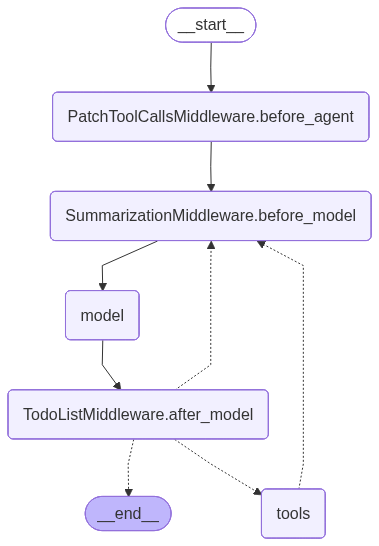

In [18]:
agent

In [20]:
### Tools
import os
from typing import Literal
from tavily import TavilyClient
from deepagents import create_deep_agent

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

agent = create_deep_agent(
    model=model,
    tools=[internet_search]
)
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent in Agentic AI?"}]})
result

{'messages': [HumanMessage(content='What is deepagent in Agentic AI?', additional_kwargs={}, response_metadata={}, id='69e9c583-1d34-434c-8e41-c738f304dd3f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 179, 'prompt_tokens': 4518, 'total_tokens': 4697, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 4480}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Cw0gZziJDWPV92ctxVNPRkpCzTPZI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ba189-648b-7ad2-b64f-308d8b3b40e4-0', tool_calls=[{'name': 'internet_search', 'args': {'query': 'deepagent Agentic AI what is Deepagent', 'max_results': 5, 'topic': 'general', 'include_raw_content': False}, 'id': 'call_zeMOL3WtSWtgfh